In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animals10' dataset.
Path to dataset files: /kaggle/input/animals10


In [ ]:
import tensorflow as tf

# Check for GPU availability
gpu_available = tf.config.list_physical_devices('GPU')
if gpu_available:
    print('GPU is available:')
    for gpu in gpu_available:
        print(f'- {gpu}')
else:
    print('No GPU found. Model training will run on CPU.')

GPU is available:
- PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
import os
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the base directory where the dataset was downloaded by kagglehub
# Assuming `path` variable from the previous cell contains the dataset path.
# We need to adjust it to point to the actual image folders.

# The structure of 'animals10' dataset is typically 'raw-img' inside the extracted path.
# We will create a simplified structure for ImageDataGenerator.

dataset_base_path = os.path.join(path, 'raw-img')

# Create train and validation directories
train_dir = 'data/train'
val_dir = 'data/validation'

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Define a split ratio
split_ratio = 0.8

# Iterate through each animal class (subdirectory in dataset_base_path)
for class_name in os.listdir(dataset_base_path):
    class_path = os.path.join(dataset_base_path, class_name)
    if os.path.isdir(class_path):
        images = [os.path.join(class_path, img) for img in os.listdir(class_path)]
        num_images = len(images)
        num_train = int(split_ratio * num_images)

        # Shuffle images before splitting
        import random
        random.shuffle(images)

        train_images = images[:num_train]
        val_images = images[num_train:]

        # Create class directories in train and validation sets
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

        # Copy images to respective directories
        for img_path in train_images:
            shutil.copy(img_path, os.path.join(train_dir, class_name, os.path.basename(img_path)))
        for img_path in val_images:
            shutil.copy(img_path, os.path.join(val_dir, class_name, os.path.basename(img_path)))

print(f"Dataset prepared. Train images in '{train_dir}', Validation images in '{val_dir}'")

# Image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data augmentation and preprocessing for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Preprocessing for validation data (only rescaling)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Load images from directories using the generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

NUM_CLASSES = train_generator.num_classes
print(f"Number of classes: {NUM_CLASSES}")

Dataset prepared. Train images in 'data/train', Validation images in 'data/validation'
Found 25138 images belonging to 10 classes.
Found 9441 images belonging to 10 classes.
Number of classes: 10


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load the pre-trained VGG16 model without the top (classification) layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the layers of the pre-trained model to prevent them from being updated during training
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers on top of VGG16
x = base_model.output
x = Flatten()(x) # Flatten the output of the VGG16 convolutional base
x = Dense(256, activation='relu')(x) # Add a fully connected layer
predictions = Dense(NUM_CLASSES, activation='softmax')(x) # Output layer for classification

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

# Train the model
# You can adjust the number of epochs based on your computational resources and desired accuracy.
EPOCHS = 20

print(f"\nStarting model training for {EPOCHS} epochs...")
with tf.device('/GPU:0'): # Ensure training happens on GPU if available
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // BATCH_SIZE
    )
print("Model training complete.")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,140,042 (80.64 MB)

 Trainable params: 6,425,354 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


Starting model training for 20 epochs...
Epoch 1/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 441s 559ms/step - accuracy: 0.6872 - loss: 0.9397 - val_accuracy: 0.8334 - val_loss: 0.5098
Epoch 2/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 56s 71ms/step - accuracy: 0.6875 - loss: 0.8975 - val_accuracy: 0.8431 - val_loss: 0.4879
Epoch 3/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 454s 578ms/step - accuracy: 0.7760 - loss: 0.6782 - val_accuracy: 0.8474 - val_loss: 0.4563
Epoch 4/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 56s 71ms/step - accuracy: 0.8125 - loss: 0.5144 - val_accuracy: 0.8492 - val_loss: 0.4498
Epoch 5/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 504s 641ms/step - accuracy: 0.7944 - loss: 0.6125 - val_accuracy: 0.8630 - val_loss: 0.4105
Epoch 6/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.7812 - loss: 0.5348 - val_accuracy: 0.8581 - val_loss: 0.4225
Epoch 7/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 434s 553ms/step - accuracy: 0.8041 - loss: 0.5861 - val_accuracy: 0.8790 - val_loss: 0.3722
Epoch 8/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import numpy as np

# Get the best validation accuracy and corresponding epoch
best_val_accuracy = np.max(history.history['val_accuracy'])
best_epoch = np.argmax(history.history['val_accuracy']) + 1

print(f"\n--- Training Summary ---")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Best Validation Accuracy achieved: {best_val_accuracy:.4f} at Epoch {best_epoch}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")


--- Training Summary ---
Final Training Accuracy: 0.8438
Final Validation Accuracy: 0.8988
Best Validation Accuracy achieved: 0.8988 at Epoch 20
Final Training Loss: 0.5659
Final Validation Loss: 0.3054


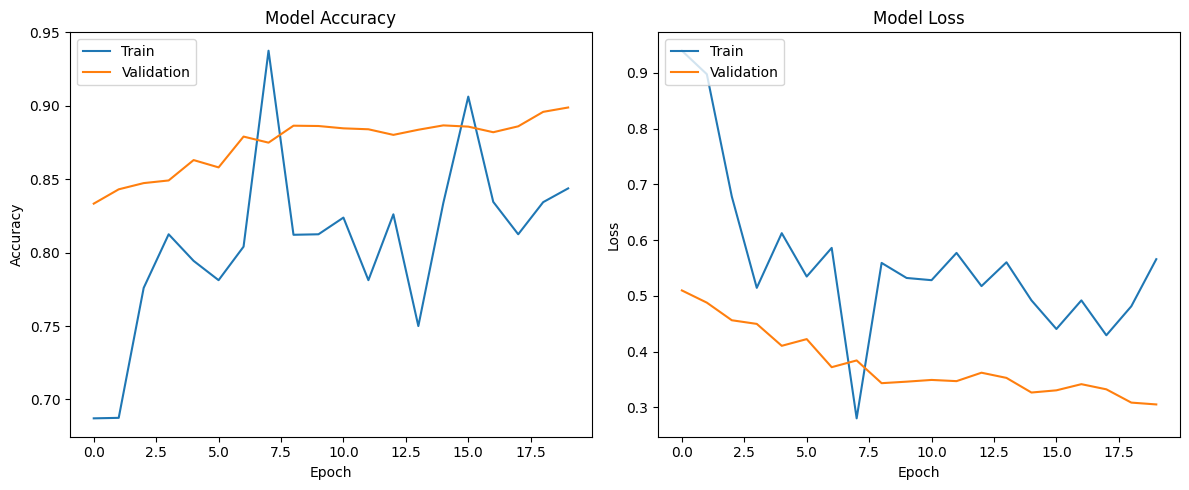

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()